# Оценка параметров АМ-сигнала на фоне шума: МП-оценка, граница Крамера—Рао и пороговый эффект

## 1. Постановка задачи

Наблюдается дискретная запись амплитудно-модулированного сигнала, искажённого аддитивным
гауссовым шумом:

$$y_n = s(t_n;\,\theta) + \varepsilon_n, \qquad
s(t;\theta) = A\bigl[1 + m\cos(2\pi f_м t + \varphi_м)\bigr]\cos(2\pi f_н t + \varphi_н),$$

где $t_n = n/f_s$, $n = 0,\dots,N{-}1$, $\varepsilon_n \sim \mathcal N(0, \sigma^2)$ — н.о.р.,
а вектор параметров $\theta = (A,\, f_н,\, f_м,\, m,\, \varphi_н,\, \varphi_м) \in \mathbb R^6$
неизвестен. **Обратная задача**: оценить $\theta$ по записи $\{y_n\}$.

Исследуемые вопросы:

1. Каков теоретический предел точности любой несмещённой оценки — **граница Крамера—Рао** (CRB)?
2. Достигают ли её практические алгоритмы, и в каком диапазоне отношения сигнал/шум (SNR)?
3. Где и почему оценки **разваливаются** — пороговый эффект: это предел информации в данных
   или предел конкретного алгоритма?
4. Как точность масштабируется с длиной записи $N$ и когда задача теряет **идентифицируемость**?

Сравниваются два метода:

- **Спектральный**: пики периодограммы с уточнением квадратичной интерполяцией;
  $\hat m$ — из отношения амплитуд боковых полос к несущей. Быстрый, неитеративный.
- **Максимальное правдоподобие (МП)**: при гауссовом шуме МП-оценка эквивалентна
  нелинейному МНК $\hat\theta = \arg\min_\theta \lVert y - s(\theta)\rVert^2$;
  решается методом доверительных областей с аналитическим якобианом,
  стартуя (а) со спектральной оценки, (б) с истинного $\theta$ — «оракульный» старт
  как диагностический инструмент, отделяющий информационный предел от алгоритмического.

Частоты выбраны **некратными** частотному разрешению $f_s/N$ — «удобных» попаданий в бины нет.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft as sp_fft
from scipy.optimize import least_squares

TAU = 2 * np.pi
COL = {"result": "#16436B", "mod": "#B3452E", "ghost": "#8FA9BC",
       "ink": "#1B3A57", "muted": "#5B7286"}
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": COL["muted"], "axes.labelcolor": COL["ink"],
    "xtick.color": COL["muted"], "ytick.color": COL["muted"],
    "axes.grid": True, "grid.color": "#DCE7EF", "grid.linewidth": 0.6,
    "axes.titlecolor": COL["ink"], "axes.titlesize": 11,
})

# истинные параметры: theta = (A, fc, fm, m, phi_c, phi_m)
THETA = np.array([1.0, 9.37, 1.83, 0.62, 0.7, -1.1])
FS, N = 100.0, 512
T_GRID = np.arange(N) / FS
PNAMES = ["A", "f_н", "f_м", "m", "φ_н", "φ_м"]


def model(theta, t):
    A, fc, fm, m, pc, pm = theta
    return A * (1 + m * np.cos(TAU * fm * t + pm)) * np.cos(TAU * fc * t + pc)


def jacobian(theta, t):
    """Аналитический якобиан ds/dtheta, размер (N, 6)."""
    A, fc, fm, m, pc, pm = theta
    wc, wm = TAU * fc * t + pc, TAU * fm * t + pm
    cwc, swc, cwm, swm = np.cos(wc), np.sin(wc), np.cos(wm), np.sin(wm)
    env = 1 + m * cwm
    J = np.empty((t.size, 6))
    J[:, 0] = env * cwc
    J[:, 1] = -A * env * swc * TAU * t
    J[:, 2] = -A * m * swm * TAU * t * cwc
    J[:, 3] = A * cwm * cwc
    J[:, 4] = -A * env * swc
    J[:, 5] = -A * m * swm * cwc
    return J


def sigma_for_snr(theta, snr_db):
    """СКО шума, дающее заданный SNR = P_signal / sigma^2."""
    p = np.mean(model(theta, T_GRID) ** 2)
    return np.sqrt(p / 10 ** (snr_db / 10))

Прежде чем чему-то верить — проверим аналитический якобиан против конечных разностей.

In [2]:
def jac_fd(theta, t, h=1e-7):
    J = np.empty((t.size, 6))
    for i in range(6):
        dp = np.zeros(6); dp[i] = h * max(1.0, abs(theta[i]))
        J[:, i] = (model(theta + dp, t) - model(theta - dp, t)) / (2 * dp[i])
    return J

err = np.max(np.abs(jacobian(THETA, T_GRID) - jac_fd(THETA, T_GRID)))
print(f"max|аналитический - конечно-разностный якобиан| = {err:.2e}")
assert err < 1e-5

max|аналитический - конечно-разностный якобиан| = 1.34e-07


## 2. Граница Крамера—Рао

Для модели $y = s(\theta) + \varepsilon$, $\varepsilon \sim \mathcal N(0, \sigma^2 I)$,
информационная матрица Фишера имеет вид

$$\mathcal I(\theta) = \frac{1}{\sigma^2}\, J^{\mathsf T} J,
\qquad J_{ni} = \frac{\partial s(t_n;\theta)}{\partial \theta_i},$$

и ковариация любой несмещённой оценки ограничена снизу:
$\operatorname{cov}(\hat\theta) \succeq \mathcal I^{-1}(\theta)$.
Для частоты одиночной синусоиды отсюда следует классический результат Райфа—Бурстина (1974):
$\operatorname{var}(\hat f) = O(N^{-3})$ — дисперсия оценки частоты падает
на порядок быстрее, чем у амплитуды ($O(N^{-1})$). Ниже мы проверим оба показателя степени
экспериментально (раздел 5).

In [3]:
def crb_std(theta, t, sigma):
    """Нижние границы СКО несмещённых оценок: sqrt(diag(I^-1))."""
    J = jacobian(theta, t)
    return sigma * np.sqrt(np.diag(np.linalg.inv(J.T @ J)))


def fim_corr(theta, t):
    """Корреляционная матрица, индуцированная I^-1."""
    C = np.linalg.inv(jacobian(theta, t).T @ jacobian(theta, t))
    d = np.sqrt(np.diag(C))
    return C / np.outer(d, d)

s10 = crb_std(THETA, T_GRID, sigma_for_snr(THETA, 10.0))
print("нижние границы СКО при SNR = 10 дБ, N = 512:")
for name, v, tr in zip(PNAMES, s10, THETA):
    print(f"  {name:4s}: {v:.2e}   (истинное значение {tr:+.2f})")

rho = fim_corr(THETA, T_GRID)
print(f"\nкорреляция ошибок (f_н, φ_н) из I^-1: {rho[1, 4]:+.3f}")
print("→ частота и фаза несущей почти коллинеарны: время отсчитывается от края записи,")
print("  и сдвиг частоты компенсируется сдвигом фазы (лечится центрированием оси времени).")

нижние границы СКО при SNR = 10 дБ, N = 512:
  A   : 1.55e-02   (истинное значение +1.00)
  f_н : 1.45e-03   (истинное значение +9.37)
  f_м : 3.89e-03   (истинное значение +1.83)
  m   : 2.42e-02   (истинное значение +0.62)
  φ_н : 2.71e-02   (истинное значение +0.70)
  φ_м : 7.20e-02   (истинное значение -1.10)

корреляция ошибок (f_н, φ_н) из I^-1: -0.857
→ частота и фаза несущей почти коллинеарны: время отсчитывается от края записи,
  и сдвиг частоты компенсируется сдвигом фазы (лечится центрированием оси времени).


## 3. Два алгоритма оценивания

**Спектральный.** Периодограмма с окном Ханна; положение пика уточняется квадратичной
интерполяцией лог-амплитуд трёх соседних бинов (лог-парабола), что снимает ошибку
дискретизации сетки частот. Боковые полосы ищутся в физически осмысленной полосе отстроек;
$\hat f_м$ — среднее отстроек двух полос, $\hat m = (a_- + a_+)/a_c$
(оконные коэффициенты усиления в отношении сокращаются). Фазы этим методом не оцениваются.

**МП/НМНК.** Минимизация $\lVert y - s(\theta)\rVert^2$ методом trust-region reflective
с аналитическим якобианом и физическими ограничениями ($m \in [0,1]$, частоты в полосе).
Старт: частоты, $m$ и $A$ — от спектральной оценки, фазы — грубым перебором по сетке
$8\times8$ (невязка считается за микросекунды, поэтому перебор дешевле любых хитростей).

In [4]:
HANN = 0.5 * (1 - np.cos(TAU * np.arange(N) / (N - 1)))
FREQS = sp_fft.rfftfreq(N, 1 / FS)
DF = FREQS[1]


def _peak_interp(loga, k):
    """Квадратичная интерполяция вершины по трём точкам лог-спектра."""
    a, b, c = loga[k - 1], loga[k], loga[k + 1]
    denom = a - 2 * b + c
    d = 0.0 if denom == 0 else np.clip(0.5 * (a - c) / denom, -0.5, 0.5)
    return k + d, np.exp(b - 0.25 * (a - c) * d)


def estimate_spectral(y, fm_band=(0.5, 5.0)):
    """(f_c, f_m, m, A) по периодограмме. Фазы не оцениваются."""
    amp = np.abs(sp_fft.rfft(y * HANN))
    loga = np.log(np.maximum(amp, 1e-300))
    # несущая ищется так, чтобы полосы поиска боковых не выходили за [0, f_s/2]
    lo = max(2, int((1.0 + fm_band[1]) / DF))
    hi = min(len(amp) - 3, int((FS / 2 - fm_band[1]) / DF))
    k_c = lo + np.argmax(amp[lo:hi])
    kc_ref, a_c = _peak_interp(loga, k_c)
    f_c = kc_ref * DF

    def side(sign):
        f_from, f_to = f_c + sign * fm_band[1], f_c + sign * fm_band[0]
        k1, k2 = sorted((int(f_from / DF), int(f_to / DF)))
        k1, k2 = max(k1, 2), min(k2, len(amp) - 3)
        if k2 < k1:  # полоса поиска выродилась (возможно только при грубом промахе по несущей)
            return 0.5 * (fm_band[0] + fm_band[1]), float(np.median(amp))
        k = k1 + np.argmax(amp[k1:k2 + 1])
        kr, a = _peak_interp(loga, k)
        return abs(kr * DF - f_c), a

    off_l, a_l = side(-1)
    off_u, a_u = side(+1)
    f_m = 0.5 * (off_l + off_u)
    m = np.clip((a_l + a_u) / a_c, 0.0, 1.0)
    A = np.sqrt(2 * np.mean(y ** 2) / (1 + 0.5 * m ** 2))
    return f_c, f_m, m, A


LB = np.array([0.05, 1.0, 0.2, 0.0, -TAU, -TAU])
UB = np.array([10.0, 45.0, 5.0, 1.0, TAU, TAU])


def estimate_mle(y, theta0):
    theta0 = np.clip(theta0, LB + 1e-9, UB - 1e-9)  # проекция старта на допустимое множество
    res = least_squares(lambda th: model(th, T_GRID) - y, theta0,
                        jac=lambda th: jacobian(th, T_GRID),
                        bounds=(LB, UB), method="trf", x_scale="jac", max_nfev=300)
    return res.x


def init_from_spectral(y):
    f_c, f_m, m, A = estimate_spectral(y)
    grid = np.linspace(0, TAU, 9)[:-1]
    best, best_sse = (0.0, 0.0), np.inf
    for pc in grid:
        for pm in grid:
            sse = np.sum((model([A, f_c, f_m, m, pc, pm], T_GRID) - y) ** 2)
            if sse < best_sse:
                best, best_sse = (pc, pm), sse
    return np.array([A, f_c, f_m, m, *best])

Иллюстрация на одной реализации при SNR = 10 дБ: сигнал в шуме, периодограмма
с найденными пиками и таблица «истина / спектральная оценка / МП».

          истина   спектр.        МП
A         1.0000    1.0747    1.0159
f_н       9.3700    9.3714    9.3702
f_м       1.8300    1.8300    1.8288
m         0.6200    0.6168    0.6111


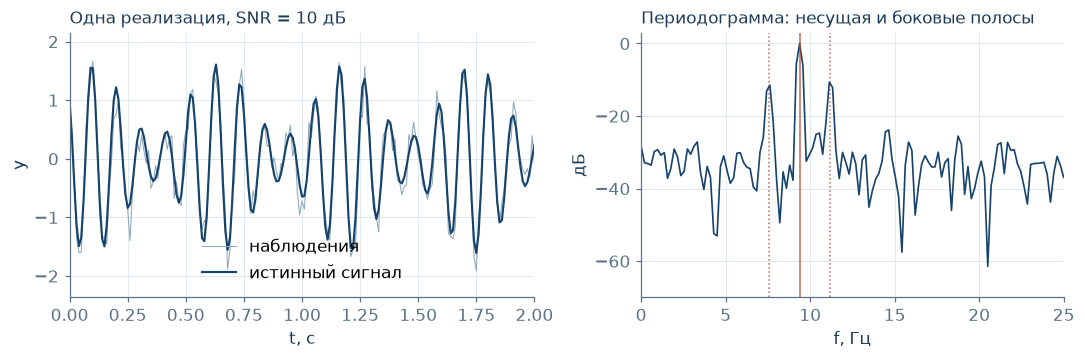

In [5]:
rng = np.random.default_rng(7)
sigma_ill = sigma_for_snr(THETA, 10.0)
y_ill = model(THETA, T_GRID) + sigma_ill * rng.normal(size=N)

th_sp = estimate_spectral(y_ill)
th_mle = estimate_mle(y_ill, init_from_spectral(y_ill))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4), width_ratios=[1.1, 1])
ax1.plot(T_GRID, y_ill, color=COL["ghost"], lw=0.7, label="наблюдения")
ax1.plot(T_GRID, model(THETA, T_GRID), color=COL["result"], lw=1.4, label="истинный сигнал")
ax1.set_xlim(0, 2); ax1.set_xlabel("t, с"); ax1.set_ylabel("y")
ax1.set_title("Одна реализация, SNR = 10 дБ", loc="left")
ax1.legend(frameon=False)

amp = np.abs(sp_fft.rfft(y_ill * HANN))
ax2.plot(FREQS, 20 * np.log10(amp / amp.max()), color=COL["result"], lw=1.1)
for f, ls in [(th_sp[0], "-"), (th_sp[0] - th_sp[1], ":"), (th_sp[0] + th_sp[1], ":")]:
    ax2.axvline(f, color=COL["mod"], lw=1, ls=ls, alpha=0.8)
ax2.set_xlim(0, 25); ax2.set_ylim(-70, 3)
ax2.set_xlabel("f, Гц"); ax2.set_ylabel("дБ")
ax2.set_title("Периодограмма: несущая и боковые полосы", loc="left")
fig.tight_layout()

print(f"{'':6s}{'истина':>10s}{'спектр.':>10s}{'МП':>10s}")
sp_map = {"A": th_sp[3], "f_н": th_sp[0], "f_м": th_sp[1], "m": th_sp[2]}
for i, name in enumerate(PNAMES[:4]):
    print(f"{name:6s}{THETA[i]:10.4f}{sp_map[name]:10.4f}{th_mle[i]:10.4f}")

## 4. Монте-Карло: эффективность оценок и пороговый эффект

Для каждого уровня SNR разыгрываем $K$ независимых реализаций шума и считаем
эмпирические СКО ошибок трёх оценок ($f_н$, $f_м$, $m$), сравнивая их с $\sqrt{\text{CRB}}$.

Ожидаемая картина из теории оценивания: выше некоторого порога МП-оценка
**асимптотически эффективна** (ложится на CRB), ниже порога начинаются грубые промахи —
пик периодограммы захватывается выбросом шума, и ошибка перестаёт быть «малой и гауссовой».
Оракульный старт покажет, чей это порог: информации или алгоритма инициализации.

In [6]:
SNR_GRID = np.arange(-20, 31, 2.5)
K = 150
EST_IDX = [1, 2, 3]  # f_c, f_m, m

rmse = {name: np.zeros((len(SNR_GRID), 3)) for name in ("spec", "mle", "oracle")}
crb = np.zeros((len(SNR_GRID), 3))

for i, snr in enumerate(SNR_GRID):
    sigma = sigma_for_snr(THETA, snr)
    crb[i] = crb_std(THETA, T_GRID, sigma)[EST_IDX]
    err = {name: np.zeros((K, 3)) for name in rmse}
    for k in range(K):
        r = np.random.default_rng(10_000 * i + k)
        y = model(THETA, T_GRID) + sigma * r.normal(size=N)
        f_c, f_m, m, _ = estimate_spectral(y)
        err["spec"][k] = [f_c - THETA[1], f_m - THETA[2], m - THETA[3]]
        err["mle"][k] = estimate_mle(y, init_from_spectral(y))[EST_IDX] - THETA[EST_IDX]
        oracle0 = np.clip(THETA * 1.001, LB + 1e-9, UB - 1e-9)
        err["oracle"][k] = estimate_mle(y, oracle0)[EST_IDX] - THETA[EST_IDX]
    for name in rmse:
        rmse[name][i] = np.sqrt(np.mean(err[name] ** 2, axis=0))

print(f"готово: {len(SNR_GRID)} уровней SNR x {K} реализаций x 2 запуска НМНК")

готово: 21 уровней SNR x 150 реализаций x 2 запуска НМНК


пороги развала (отрыв от CRB > 3x):
  МП, старт со спектра:   f_н <= -10.0 дБ,  f_м <= +0.0 дБ,  m: нет
  МП, оракульный старт:   f_н: нет,  f_м: нет,  m: нет


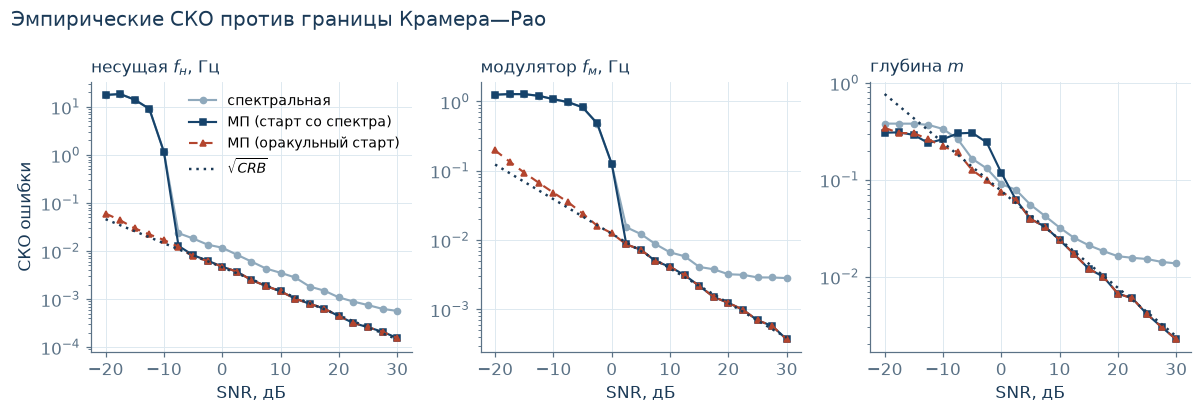

In [7]:
titles = ["несущая $f_н$, Гц", "модулятор $f_м$, Гц", "глубина $m$"]
series = [("spec", "спектральная", COL["ghost"], "-", "o"),
          ("mle", "МП (старт со спектра)", COL["result"], "-", "s"),
          ("oracle", "МП (оракульный старт)", COL["mod"], (0, (4, 3)), "^")]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), sharex=True)
for j, (ax, title) in enumerate(zip(axes, titles)):
    for name, label, color, ls, mk in series:
        ax.semilogy(SNR_GRID, rmse[name][:, j], color=color, ls=ls, marker=mk,
                    ms=4, lw=1.4, label=label)
    ax.semilogy(SNR_GRID, crb[:, j], color=COL["ink"], ls=(0, (1, 2)), lw=1.6,
                label=r"$\sqrt{CRB}$")
    ax.set_title(title, loc="left")
    ax.set_xlabel("SNR, дБ")
axes[0].set_ylabel("СКО ошибки")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Эмпирические СКО против границы Крамера—Рао", x=0.01, ha="left", color=COL["ink"])
fig.tight_layout()

# порог: наибольший SNR, при котором оценка оторвана от CRB более чем втрое
def thresholds(name):
    out = []
    for j, pname in enumerate(["f_н", "f_м", "m"]):
        above = rmse[name][:, j] > 3 * crb[:, j]
        out.append(f"{pname} <= {SNR_GRID[np.nonzero(above)[0].max()]:+.1f} дБ"
                   if above.any() else f"{pname}: нет")
    return ",  ".join(out)

print("пороги развала (отрыв от CRB > 3x):")
print("  МП, старт со спектра:  ", thresholds("mle"))
print("  МП, оракульный старт:  ", thresholds("oracle"))

Чтение графика:

- **Выше порога МП-оценка лежит на CRB** по всем трём параметрам — асимптотическая
  эффективность воспроизведена экспериментально, оценщик выжимает из данных всю информацию.
- **Спектральная оценка** близка к CRB по $f_н$ (несущая — самый мощный пик), но проигрывает
  по $f_м$ и $m$: боковые полосы на ~10 дБ слабее несущей, и их пики зашумлены сильнее;
  кроме того, квадратичная интерполяция лог-параболой — лишь приближение формы пика окна Ханна.
- **Порог параметрозависим**: боковые полосы на $\sim$10 дБ слабее несущей
  (отношение амплитуд $m/2 \approx 0.31$), поэтому параметры модулятора $(f_м, m)$
  разваливаются при заметно большем SNR, чем несущая, — у порога есть «этажность»
  по иерархии мощностей компонент сигнала.
- **Пороговый эффект**: ниже порога кривые МП со спектральным стартом взлетают на порядки —
  это не «постепенное ухудшение», а лавина грубых промахов. Оракульный старт держится CRB
  заметно дольше ⇒ в окрестности порога отказывает **инициализация** (захват ложного пика),
  а не информация в данных. Ещё ниже отрывается и оракул — там уже честный
  информационный предел: функция правдоподобия становится мультимодальной,
  и глобальный максимум с вероятностью, не стремящейся к нулю, оказывается у ложного пика.
  Это классическая картина нелинейного оценивания частоты (Rife & Boorstyn, 1974).
- **Осторожно с CRB при низком SNR**: на панели $m$ эмпирические СКО опускаются *ниже*
  границы. Это не парадокс и не ошибка: оценка $\hat m$ ограничена отрезком $[0,1]$
  и потому смещена, а CRB ограничивает снизу дисперсию только **несмещённых** оценок.
  Смещённые (в т.ч. байесовские и ограниченные) оценки вправе её нарушать,
  расплачиваясь смещением.

## 5. Масштабирование с длиной записи

CRB предсказывает разные скорости: $\operatorname{СКО}(\hat f) \propto N^{-3/2}$,
$\operatorname{СКО}(\hat m) \propto N^{-1/2}$. Проверим показатели степени
на МП-оценке при фиксированном SNR = 15 дБ.

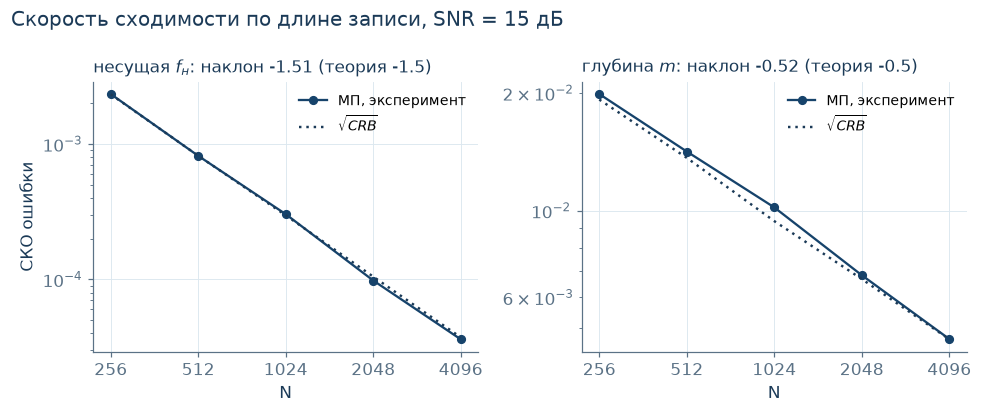

In [8]:
N_LIST = np.array([256, 512, 1024, 2048, 4096])
K_N = 100
SNR_FIX = 15.0

rmse_n = np.zeros((len(N_LIST), 3))
crb_n = np.zeros((len(N_LIST), 3))
for i, n in enumerate(N_LIST):
    t = np.arange(n) / FS
    hann_n = 0.5 * (1 - np.cos(TAU * np.arange(n) / (n - 1)))
    sig = model(THETA, t)
    sigma = np.sqrt(np.mean(sig ** 2) / 10 ** (SNR_FIX / 10))
    J = jacobian(THETA, t)
    crb_n[i] = (sigma * np.sqrt(np.diag(np.linalg.inv(J.T @ J))))[EST_IDX]
    errs = np.zeros((K_N, 3))
    for k in range(K_N):
        r = np.random.default_rng(77_000 * i + k)
        y = sig + sigma * r.normal(size=n)
        th0 = np.clip(THETA * 1.001, LB + 1e-9, UB - 1e-9)
        fit = least_squares(lambda th: model(th, t) - y, th0,
                            jac=lambda th: jacobian(th, t),
                            bounds=(LB, UB), method="trf", x_scale="jac", max_nfev=300)
        errs[k] = fit.x[EST_IDX] - THETA[EST_IDX]
    rmse_n[i] = np.sqrt(np.mean(errs ** 2, axis=0))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, j, title, expo in [(axes[0], 0, "несущая $f_н$", -1.5), (axes[1], 2, "глубина $m$", -0.5)]:
    ax.loglog(N_LIST, rmse_n[:, j], "o-", color=COL["result"], lw=1.5, ms=5, label="МП, эксперимент")
    ax.loglog(N_LIST, crb_n[:, j], ls=(0, (1, 2)), color=COL["ink"], lw=1.6, label=r"$\sqrt{CRB}$")
    slope = np.polyfit(np.log(N_LIST), np.log(rmse_n[:, j]), 1)[0]
    ax.set_title(f"{title}: наклон {slope:.2f} (теория {expo})", loc="left")
    ax.set_xlabel("N"); ax.set_xticks(N_LIST, [str(v) for v in N_LIST])
    ax.tick_params(axis="x", which="minor", bottom=False, labelbottom=False)
    ax.legend(frameon=False, fontsize=9)
axes[0].set_ylabel("СКО ошибки")
fig.suptitle("Скорость сходимости по длине записи, SNR = 15 дБ", x=0.01, ha="left", color=COL["ink"])
fig.tight_layout()

## 6. Идентифицируемость: что происходит при $m \to 0$

При слабой модуляции боковые полосы исчезают, и параметры модулятора $(f_м, \varphi_м)$
перестают проявляться в данных: информационная матрица вырождается по этим направлениям.
Из структуры якобиана видно, что $\partial s/\partial f_м$ и $\partial s/\partial \varphi_м$
пропорциональны $m$, поэтому $\text{CRB}(\hat f_м),\, \text{CRB}(\hat\varphi_м) \propto m^{-2}$,
т.е. нижние границы СКО растут как $m^{-1}$. Никакой алгоритм этого не обойдёт —
это свойство задачи, а не метода. Шум фиксируем по мощности несущей ($A^2/2$),
чтобы изменение $m$ не меняло SNR само по себе.

наклоны log-log: CRB(f_м) -1.000, CRB(φ_м) -1.000 (теория: -1)


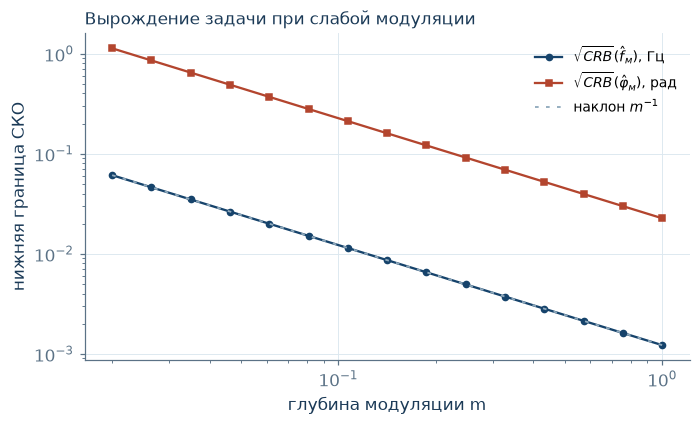

In [9]:
m_grid = np.logspace(np.log10(0.02), 0, 15)
sigma_fix = np.sqrt((THETA[0] ** 2 / 2) / 10 ** (SNR_FIX / 10))

crb_m = np.array([crb_std(np.r_[THETA[:3], mm, THETA[4:]], T_GRID, sigma_fix)
                  for mm in m_grid])

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.loglog(m_grid, crb_m[:, 2], "o-", color=COL["result"], lw=1.5, ms=4,
          label=r"$\sqrt{CRB}(\hat f_м)$, Гц")
ax.loglog(m_grid, crb_m[:, 5], "s-", color=COL["mod"], lw=1.5, ms=4,
          label=r"$\sqrt{CRB}(\hat \varphi_м)$, рад")
ref = crb_m[-1, 2] * (m_grid / m_grid[-1]) ** (-1.0)
ax.loglog(m_grid, ref, ls=(0, (2, 4)), color=COL["ghost"], lw=1.2, label="наклон $m^{-1}$")
ax.set_xlabel("глубина модуляции m"); ax.set_ylabel("нижняя граница СКО")
ax.set_title("Вырождение задачи при слабой модуляции", loc="left")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()

s1, s2 = (np.polyfit(np.log(m_grid), np.log(crb_m[:, i]), 1)[0] for i in (2, 5))
print(f"наклоны log-log: CRB(f_м) {s1:.3f}, CRB(φ_м) {s2:.3f} (теория: -1)")

## 7. Выводы

1. **МП-оценка асимптотически эффективна**: выше порога эмпирические СКО всех параметров
   совпадают с границей Крамера—Рао — метод извлекает из данных всю доступную информацию.
2. **Спектральная оценка** конкурентоспособна только по несущей; по параметрам модулятора
   она платит за слабость боковых полос и приближённость интерполяции пика.
   Её правильная роль — дешёвая инициализация для МП.
3. **Пороговый эффект имеет двухслойную природу**: сначала (при умеренно низком SNR)
   отказывает инициализация — захват ложного пика периодограммы, что видно по расхождению
   стартов «спектральный» и «оракульный»; при ещё меньшем SNR мультимодальность
   правдоподобия делает грубые промахи неизбежными для любого метода.
4. **Показатели скорости сходимости подтверждены**: СКО частоты убывает как $N^{-3/2}$,
   амплитудных параметров — как $N^{-1/2}$, в согласии с CRB.
5. **Идентифицируемость теряется при $m \to 0$** со скоростью $m^{-1}$ по СКО —
   вырождение информационной матрицы, присущее самой задаче.
6. Побочное наблюдение: корреляция ошибок $(\hat f_н, \hat\varphi_н)$ близка к $-1$
   при отсчёте времени от края записи; центрирование оси времени — стандартная
   репараметризация, разделяющая эти параметры.

**Дальнейшая работа**: тот же анализ для ЧМ-сигнала (там спектральная инициализация
нетривиальна — гребёнка Бесселя); учёт негауссова/окрашенного шума (обобщённый МНК);
байесовская постановка с порогом как сменой режима апостериорной плотности;
перенос Монте-Карло-контура на C++ ядро.

## Литература

1. Rife D. C., Boorstyn R. R. *Single-tone parameter estimation from discrete-time
   observations* // IEEE Trans. Inform. Theory. 1974. V. 20, № 5.
2. Kay S. M. *Fundamentals of Statistical Signal Processing. Vol. I: Estimation Theory.*
   Prentice Hall, 1993.
3. Stoica P., Moses R. *Spectral Analysis of Signals.* Prentice Hall, 2005.